In [1]:
%pip install pandas scikit-learn matplotlib seaborn numpy shap;

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Análise exploratória dos dados

### Carregamento do dataset

O dataset utilizado é o de probabilidade do paciente ser diagnosticado com Diabetes
- Fonte: [Kaggle — mathchi/diabetes-data-set](https://www.kaggle.com/datasets/mathchi/diabetes-data-set/data)



In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, r2_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.inspection import permutation_importance
import shap

%matplotlib inline

# Carregar o dataset
dados = pd.read_csv('../data/diabetes.csv')
# Exibir as primeiras linhas do dataset
dados.head(10)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [4]:
print('=== INFORMAÇÕES GERAIS ===')
dados.describe()

=== INFORMAÇÕES GERAIS ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
print(f'Dataset carregado: {dados.shape[0]} linhas e {dados.shape[1]} colunas')

Dataset carregado: 768 linhas e 9 colunas


- Temos 768 registros no dataset

- O dataset possui 8 features
    - Pregnancies (Gestações)
    - Glucose ( Glicose)
    - BloodPressure (Pressão arterial)
    - SkinThickness (Refere-se a uma medição de espessura da pele do triceps em dobra em milímetros)
    - Insulin (Insulina - 2-hour serum Insulin (mu U/ml) - Medição de Insulina após 2 horas de alimentação)
    - BMI (IMC - Indice de Massa Corporal)
    - DiabetesPedigreeFunction (Predisposição genética)
    - Age (Idade)   
- 1 Variável de classe
    - Outcome
        - 0 para negativo
        - 1 para positivo

In [6]:
dados.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
print('=== VALORES NULOS ===')
dados.isnull().sum()

=== VALORES NULOS ===


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

- Não foram identificadas colunas com dados nulos

In [8]:
print('=== CONTAGEM DE ZEROS ===')
contagem_zero = (dados == 0).sum().reset_index()
contagem_zero.columns = ['Coluna', 'Contagem de Zeros']
print(contagem_zero)

=== CONTAGEM DE ZEROS ===
                     Coluna  Contagem de Zeros
0               Pregnancies                111
1                   Glucose                  5
2             BloodPressure                 35
3             SkinThickness                227
4                   Insulin                374
5                       BMI                 11
6  DiabetesPedigreeFunction                  0
7                       Age                  0
8                   Outcome                500


Zeros suspeitos (dados ausentes disfarçados)

Algumas colunas não podem ter valor zero fisiologicamente:
- **Glucose**: glicose zero é incompatível com vida
- **BloodPressure**: pressão zero é incompatível com vida  
- **SkinThickness**: espessura de pele zero não faz sentido clínico
- **Insulin**: Não faz sentido clinico
- **BMI**: IMC zero é impossível

A coluna Insulin e SkinThickness possuem um valor muito alto de valores zerados.

In [9]:
#verificar duplicidades
dados.duplicated().sum()

np.int64(0)

- Não há duplicidades

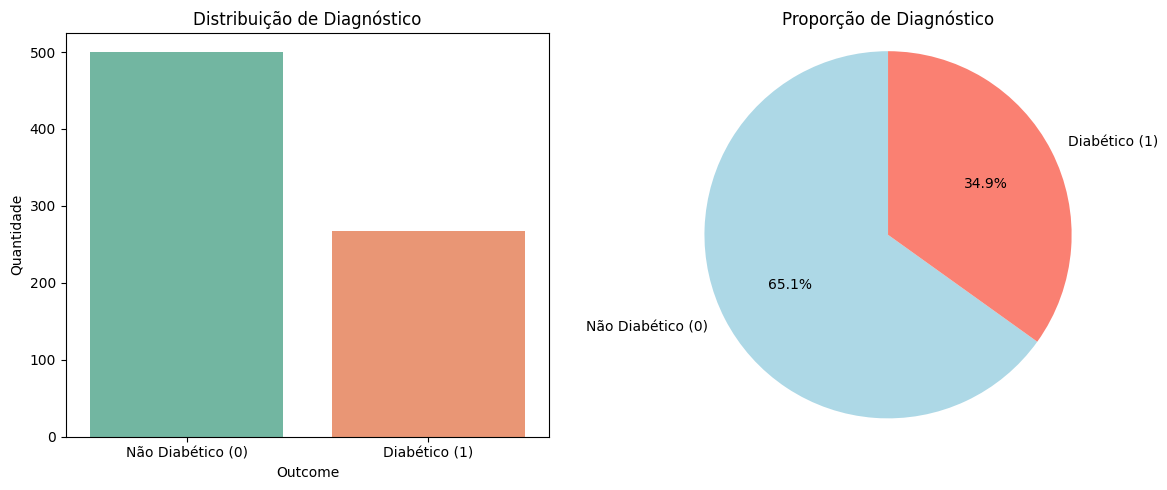

In [10]:

contagem = dados['Outcome'].value_counts()
labels = ['Não Diabético (0)', 'Diabético (1)']

fig, axes = plt.subplots(1,2, figsize=(12,5))

#Grafico de barras
sns.countplot(x='Outcome', data=dados, ax=axes[0], hue='Outcome', legend=False, palette='Set2')
axes[0].set_title('Distribuição de Diagnóstico')
axes[0].set_xlabel('Outcome')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Quantidade')

#Grafico de pizza
axes[1].pie(contagem, labels=labels, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'salmon'])
axes[1].set_title('Proporção de Diagnóstico')
axes[1].axis('equal')

plt.tight_layout()
plt.savefig('../Graficos/distribuicao_outcome.png', dpi=150, bbox_inches='tight')
plt.show()


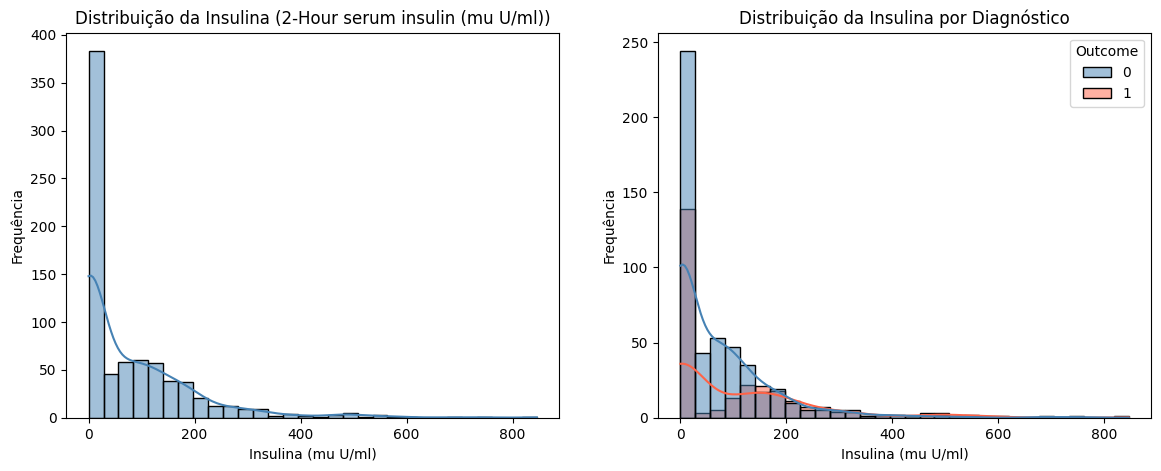

In [11]:
outcome = sorted(dados['Outcome'].unique().tolist())
color = ['steelblue', 'tomato']
labels =  ['Não Diabético (0)', 'Diabético (1)']

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(dados['Insulin'], kde=True, bins=30, ax=axes[0], color='steelblue') 
axes[0].set_title('Distribuição da Insulina (2-Hour serum insulin (mu U/ml))')
axes[0].set_xlabel('Insulina (mu U/ml)')
axes[0].set_ylabel('Frequência')

sns.histplot(data=dados, x='Insulin', hue='Outcome', kde=True, bins=30, alpha=0.5, ax=axes[1], palette=color)
axes[1].set_title('Distribuição da Insulina por Diagnóstico')
axes[1].set_xlabel('Insulina (mu U/ml)')
axes[1].set_ylabel('Frequência')
plt.savefig('../Graficos/distribuicao_insulin.png', dpi=150, bbox_inches='tight')
plt.show()  




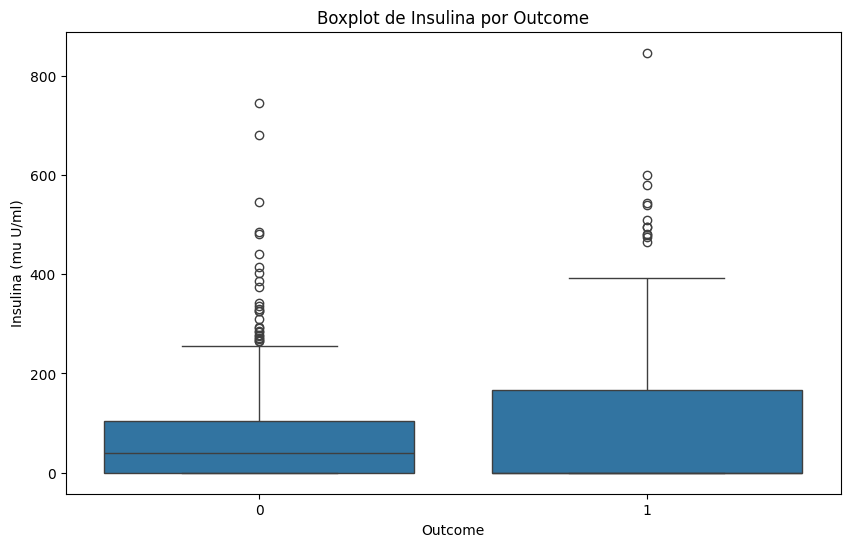

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Outcome', y='Insulin', data=dados) 
plt.title('Boxplot de Insulina por Outcome')
plt.xlabel('Outcome')
plt.ylabel('Insulina (mu U/ml)')
plt.savefig('../Graficos/boxplot_insulin.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
proporcao_zero_insulin = len(dados[dados['Insulin'] == 0]) / len(dados)
print(f'Proporção de valores zero na coluna Insulin: {proporcao_zero_insulin:.2%}')

Proporção de valores zero na coluna Insulin: 48.70%


- Tem muitos dados faltantes na coluna de insulina. 
    - O valor 0 (zero) de insulina não é compatível com a vida
    - Pesquisa: Pesquisadores usaram o valor 0 (zero) para indicar que não ocorreu análise desse valor ou houve falha ao reportar
    - Vamos tratar na fase de pré-processamento

### Glucose (Glicose)

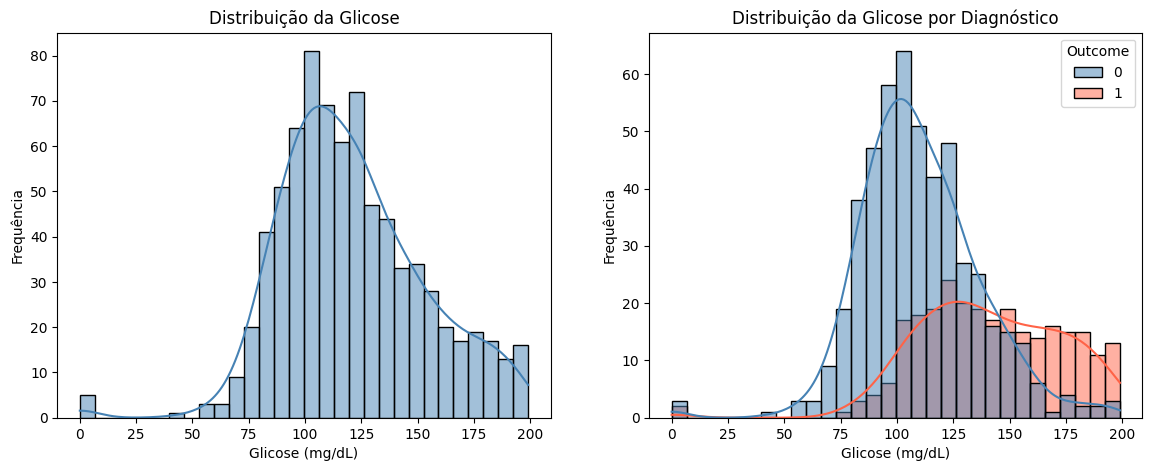

In [14]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(dados['Glucose'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição da Glicose')
axes[0].set_xlabel('Glicose (mg/dL)')
axes[0].set_ylabel('Frequência')

sns.histplot(data=dados, x='Glucose', hue='Outcome', kde=True, bins=30, alpha=0.5, ax=axes[1], palette=color)
axes[1].set_title('Distribuição da Glicose por Diagnóstico')
axes[1].set_xlabel('Glicose (mg/dL)')
axes[1].set_ylabel('Frequência')
plt.savefig('../Graficos/distribuicao_glucose.png', dpi=150, bbox_inches='tight')
plt.show()

- A glicose segue uma distribuição normal
- Valores de glicose mais alto também é onde se concentram mais diagnósticos positivos

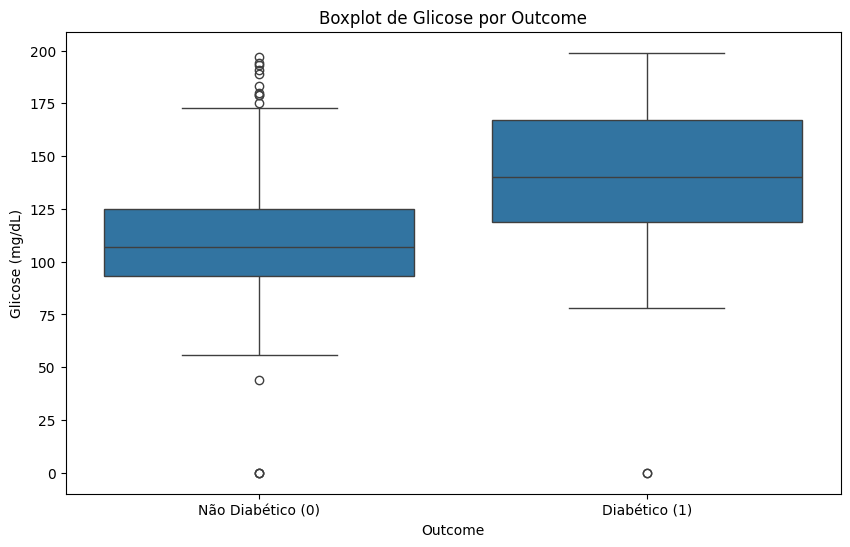

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Outcome', y='Glucose', data=dados)
plt.title('Boxplot de Glicose por Outcome')
plt.xlabel('Outcome')
plt.ylabel('Glicose (mg/dL)') 
plt.xticks(outcome, labels=labels)
plt.savefig('../Graficos/boxplot_glucose.png', dpi=150, bbox_inches='tight')  
plt.show()

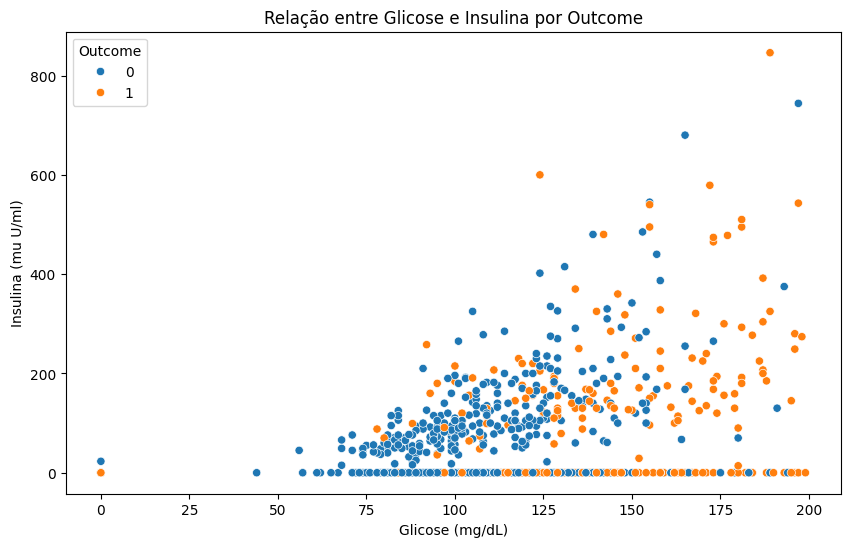

In [16]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Glucose', y='Insulin', hue='Outcome', data=dados)
plt.title('Relação entre Glicose e Insulina por Outcome')
plt.xlabel('Glicose (mg/dL)')
plt.ylabel('Insulina (mu U/ml)')
plt.savefig('../Graficos/relacao_glucose_insulin.png', dpi=150, bbox_inches='tight')    
plt.show()

- A feature glicose possui alguns valores zerados que serão tratados na fase de pré-processamento

### Pressão arterial (BloodPressure)

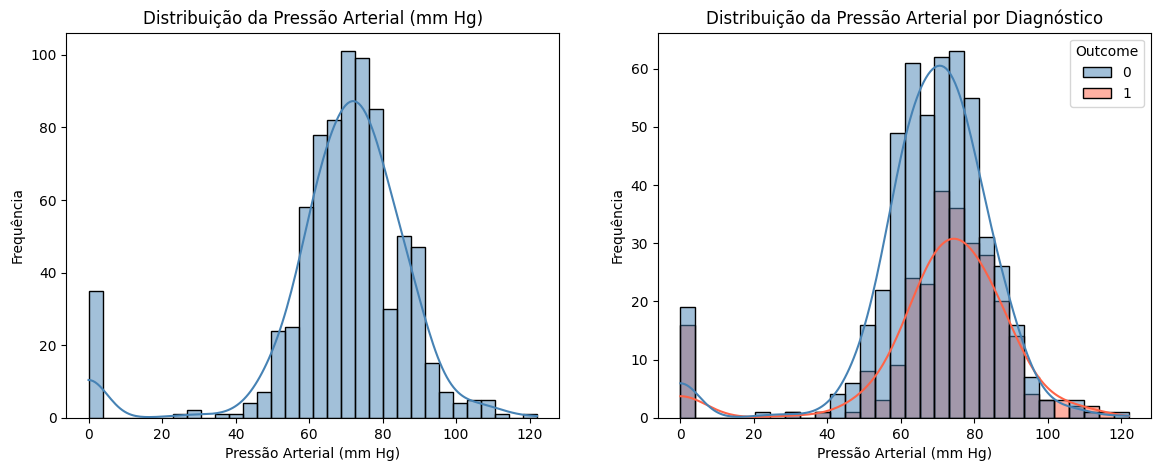

In [17]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(dados['BloodPressure'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição da Pressão Arterial (mm Hg)')
axes[0].set_xlabel('Pressão Arterial (mm Hg)')
axes[0].set_ylabel('Frequência')

sns.histplot(data=dados, x='BloodPressure', hue='Outcome', kde=True, bins=30, alpha=0.5, ax=axes[1], palette=color)
axes[1].set_title('Distribuição da Pressão Arterial por Diagnóstico')
axes[1].set_xlabel('Pressão Arterial (mm Hg)')
axes[1].set_ylabel('Frequência')
plt.savefig('../Graficos/distribuicao_blood_pressure.png', dpi=150, bbox_inches='tight')
plt.show()

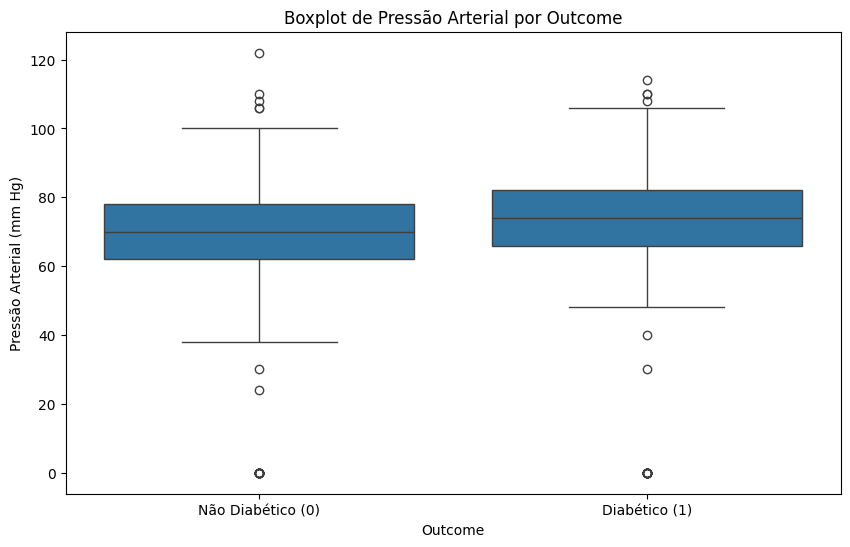

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Outcome', y='BloodPressure', data=dados) 
plt.title('Boxplot de Pressão Arterial por Outcome')
plt.xlabel('Outcome')
plt.ylabel('Pressão Arterial (mm Hg)')
plt.xticks(outcome, labels=labels)
plt.savefig('../Graficos/boxplot_blood_pressure.png', dpi=150, bbox_inches='tight')
plt.show()

- A pressão sanguinea para o diagnóstico positivo apresenta ser levemente mais alta.

### IMC (BMI)

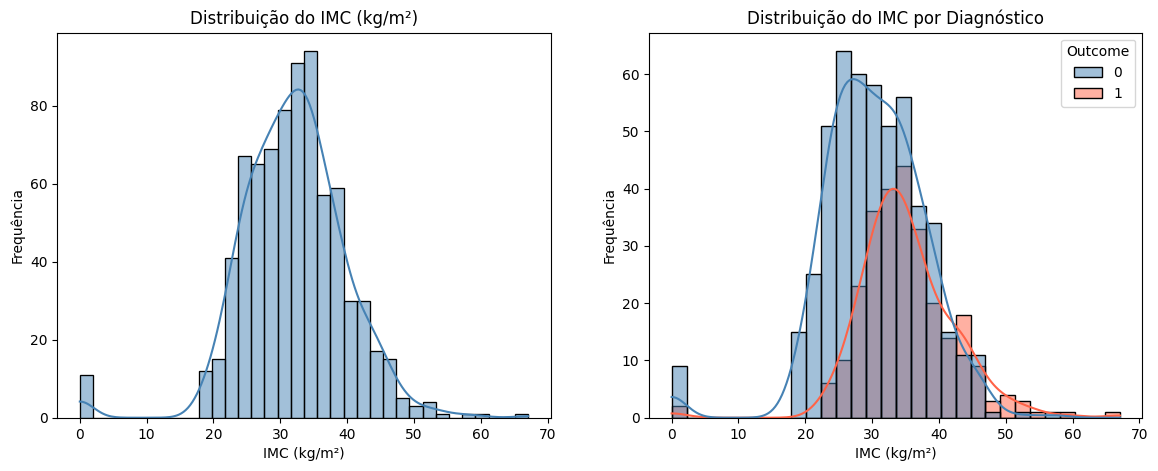

In [19]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(dados['BMI'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição do IMC (kg/m²)')
axes[0].set_xlabel('IMC (kg/m²)')
axes[0].set_ylabel('Frequência')

sns.histplot(data=dados, x='BMI', hue='Outcome', kde=True, bins=30, alpha=0.5, ax=axes[1], palette=color)
axes[1].set_title('Distribuição do IMC por Diagnóstico')
axes[1].set_xlabel('IMC (kg/m²)')
axes[1].set_ylabel('Frequência')
plt.savefig('../Graficos/distribuicao_bmi.png', dpi=150, bbox_inches='tight')
plt.show()

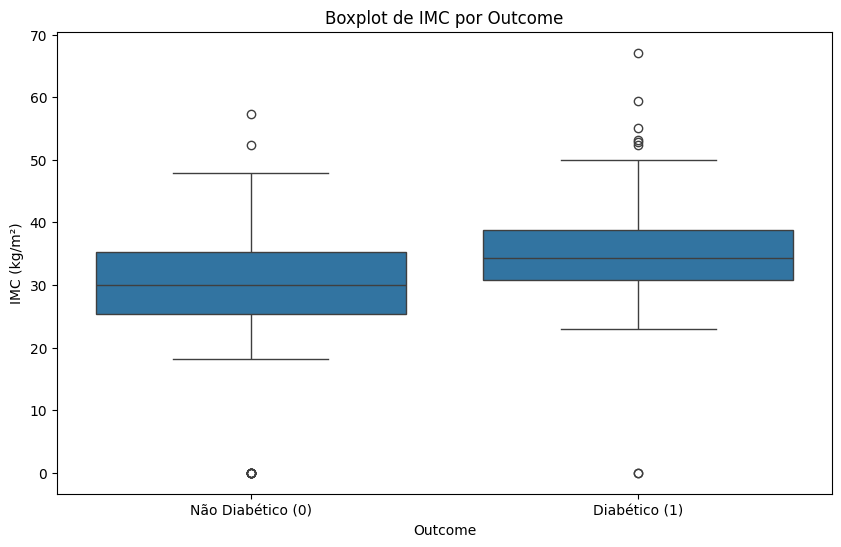

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Outcome', y='BMI', data=dados)
plt.title('Boxplot de IMC por Outcome')
plt.xlabel('Outcome')
plt.ylabel('IMC (kg/m²)')
plt.xticks(outcome, labels=labels)
plt.savefig('../Graficos/boxplot_bmi.png', dpi=150, bbox_inches='tight')
plt.show()


O IMC de indivíduos com diagnóstico positivo tende a ser um pouco maior.

### Idade (Age)

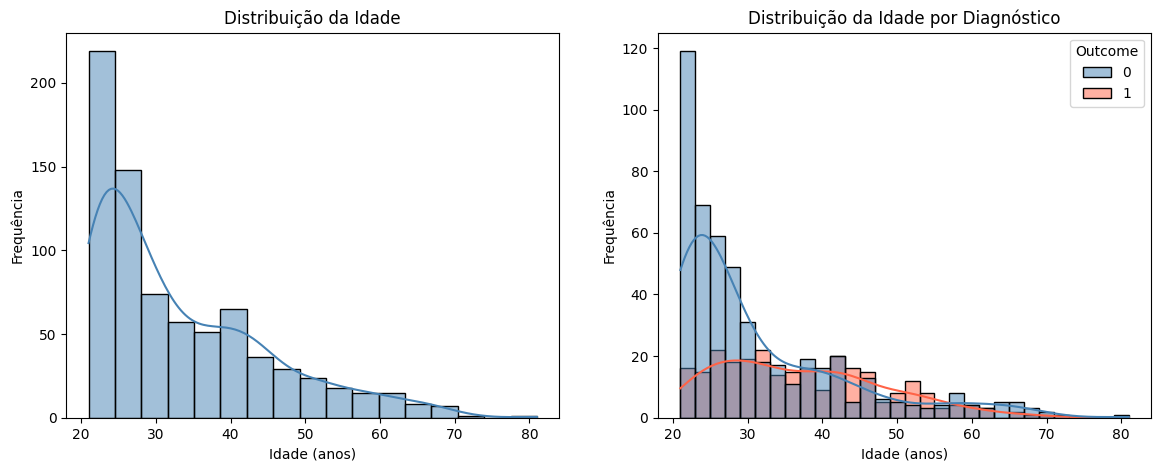

In [21]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(dados['Age'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição da Idade')
axes[0].set_xlabel('Idade (anos)')
axes[0].set_ylabel('Frequência')
sns.histplot(data=dados, x='Age', hue='Outcome', kde=True, bins=30, alpha=0.5, ax=axes[1], palette=color)
axes[1].set_title('Distribuição da Idade por Diagnóstico')
axes[1].set_xlabel('Idade (anos)')
axes[1].set_ylabel('Frequência')
plt.savefig('../Graficos/distribuicao_age.png', dpi=150, bbox_inches='tight')
plt.show()


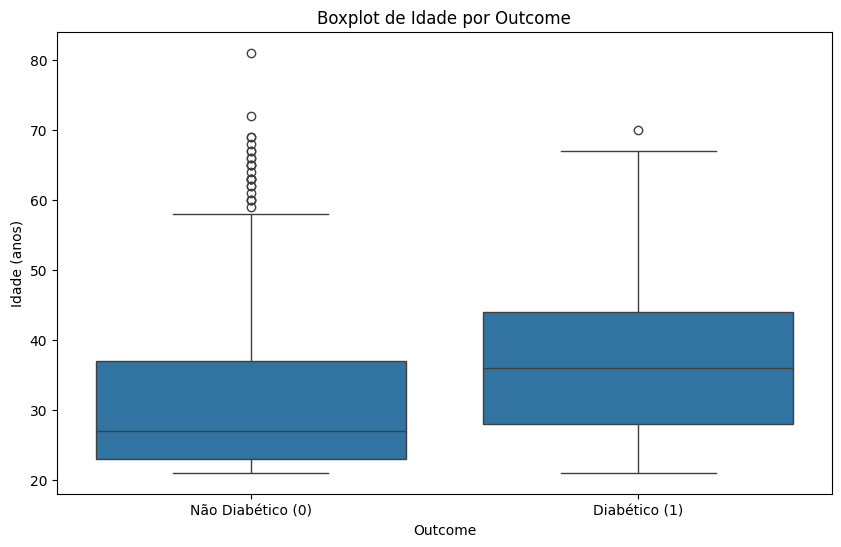

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Outcome', y='Age', data=dados) 
plt.title('Boxplot de Idade por Outcome')
plt.xlabel('Outcome')
plt.ylabel('Idade (anos)')
plt.xticks(outcome, labels=labels)
plt.savefig('../Graficos/boxplot_age.png', dpi=150, bbox_inches='tight')
plt.show()


A concentração de diagnóstico positivo tem maior concentração a partir de indivíduos após os 30 anos de idade

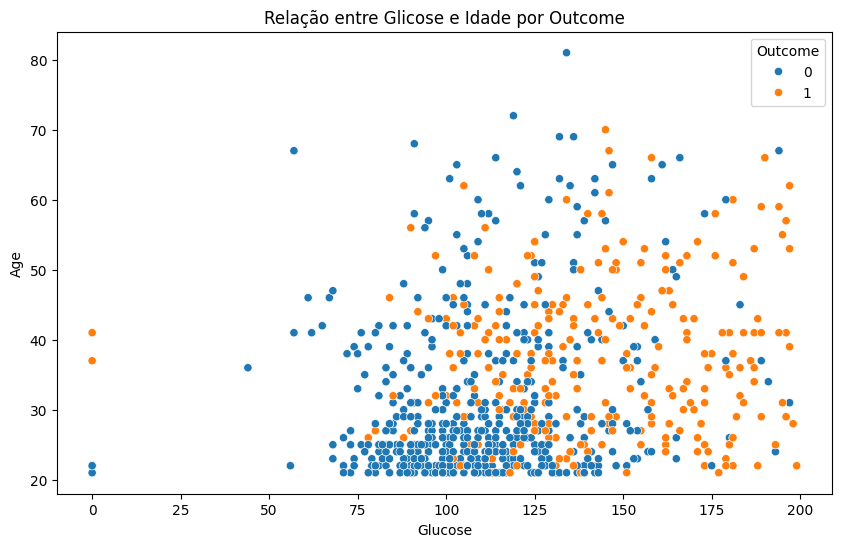

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Glucose', y='Age', hue='Outcome', data=dados)
plt.title('Relação entre Glicose e Idade por Outcome')
plt.savefig('../Graficos/relacao_glucose_age.png', dpi=150, bbox_inches='tight')
plt.show()

Nos mais jovens se concentra o diagnóstico negativo, mesmo em indivíduos com glicose média para alta, porém quanto mais alta a glicose, mesmo indivíduos jovens foram diagnosticados positivamente.
Individuos com glicose alta mas Sem diabetes podem estar 

### Propensão hereditária (DiabetesPedigreeeFunction)

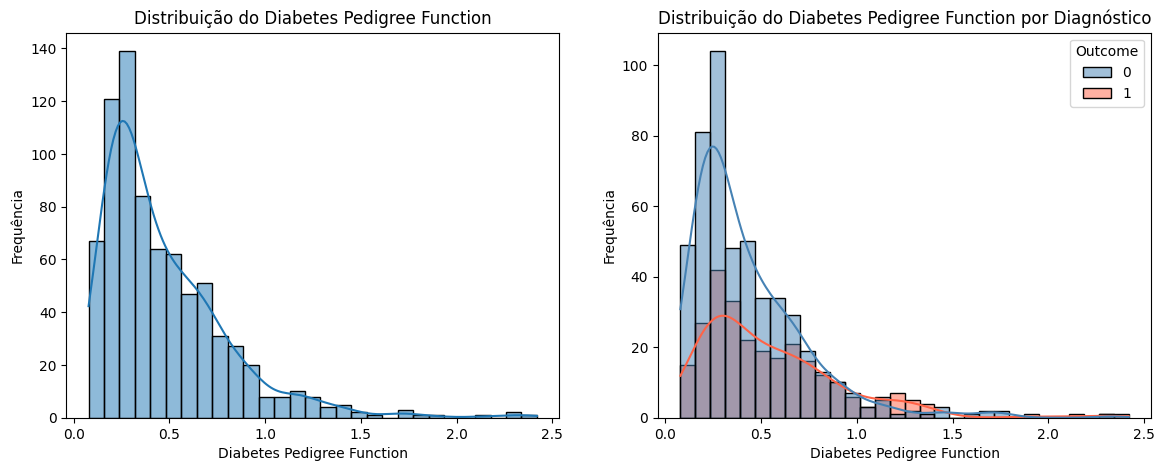

In [24]:

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(dados['DiabetesPedigreeFunction'], kde=True, ax=axes[0])
axes[0].set_title('Distribuição do Diabetes Pedigree Function')
axes[0].set_xlabel('Diabetes Pedigree Function')
axes[0].set_ylabel('Frequência')

sns.histplot(data=dados, x='DiabetesPedigreeFunction', hue='Outcome', kde=True, bins=30, alpha=0.5, ax=axes[1], palette=color)
axes[1].set_title('Distribuição do Diabetes Pedigree Function por Diagnóstico')
axes[1].set_xlabel('Diabetes Pedigree Function')
axes[1].set_ylabel('Frequência') 
plt.savefig('../Graficos/distribuicao_diabetes_pedigree_function.png', dpi=150, bbox_inches='tight')   
plt.show()


Text(0.5, 1.0, 'Relação entre Glicose e Diabetes Pedigree Function por Outcome')

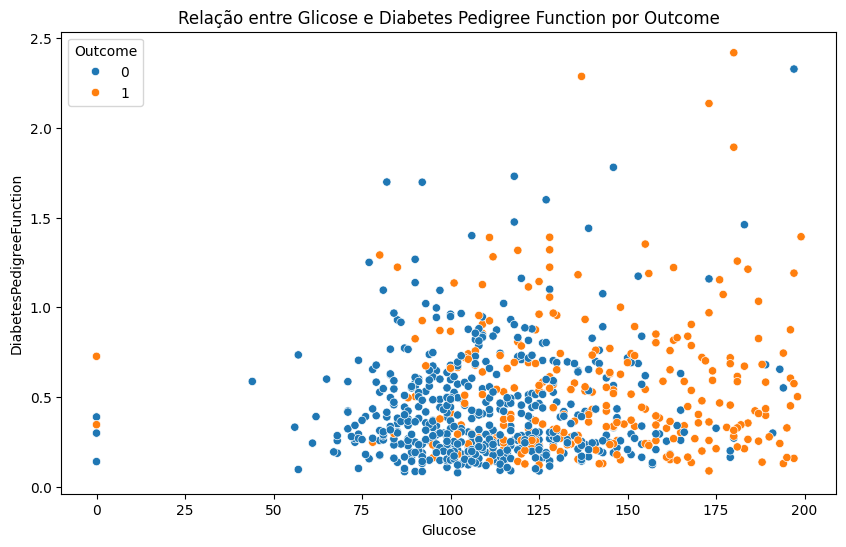

In [25]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Glucose', y='DiabetesPedigreeFunction', hue='Outcome', data=dados)
plt.title('Relação entre Glicose e Diabetes Pedigree Function por Outcome')

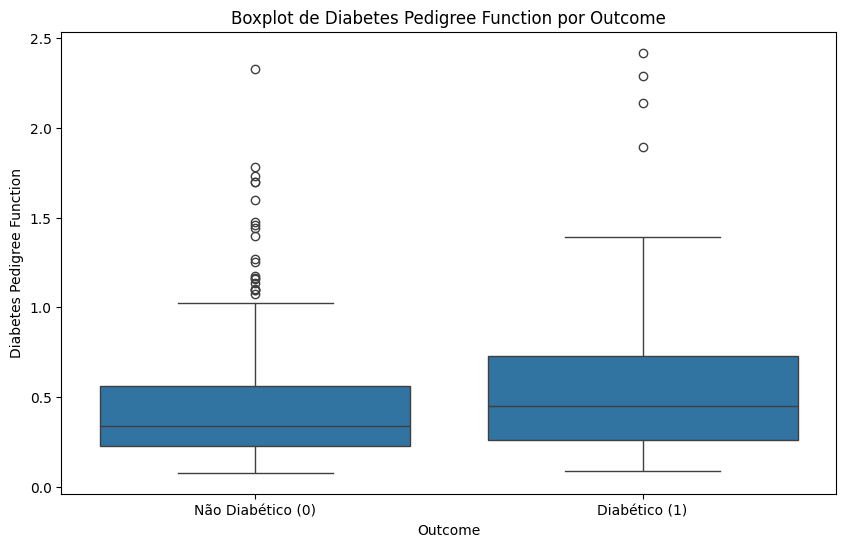

In [26]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Outcome', y='DiabetesPedigreeFunction', data=dados)
plt.title('Boxplot de Diabetes Pedigree Function por Outcome')
plt.xlabel('Outcome')
plt.ylabel('Diabetes Pedigree Function')
plt.xticks(outcome, labels=labels)
plt.savefig('../Graficos/boxplot_diabetes_pedigree_function.png', dpi=150, bbox_inches='tight')
plt.show()

No boxplot dá pra perceber que há uma concentração maior para as pessoas com propenção hereditária para diagnóstico de diabetes no diagnóstico positivo.
- Porém temos muitos outliers no resultado negativo, de pessoas com propensão mais alta a desenvolver diabetes, porém não possuem a doença no momento. 

### Espessura da pele (SkinThickness)

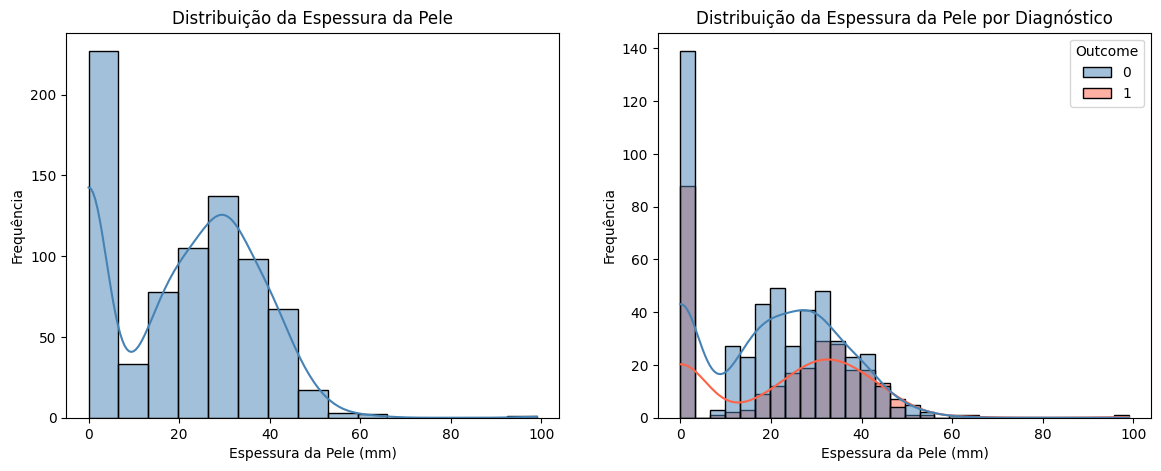

In [27]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(dados['SkinThickness'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição da Espessura da Pele')
axes[0].set_xlabel('Espessura da Pele (mm)')
axes[0].set_ylabel('Frequência')
sns.histplot(data=dados, x='SkinThickness', hue='Outcome', kde=True, bins=30, alpha=0.5, ax=axes[1], palette=color)
axes[1].set_title('Distribuição da Espessura da Pele por Diagnóstico')
axes[1].set_xlabel('Espessura da Pele (mm)')
axes[1].set_ylabel('Frequência')
plt.savefig('../Graficos/distribuicao_skinthickness.png', dpi=150, bbox_inches='tight')
plt.show()

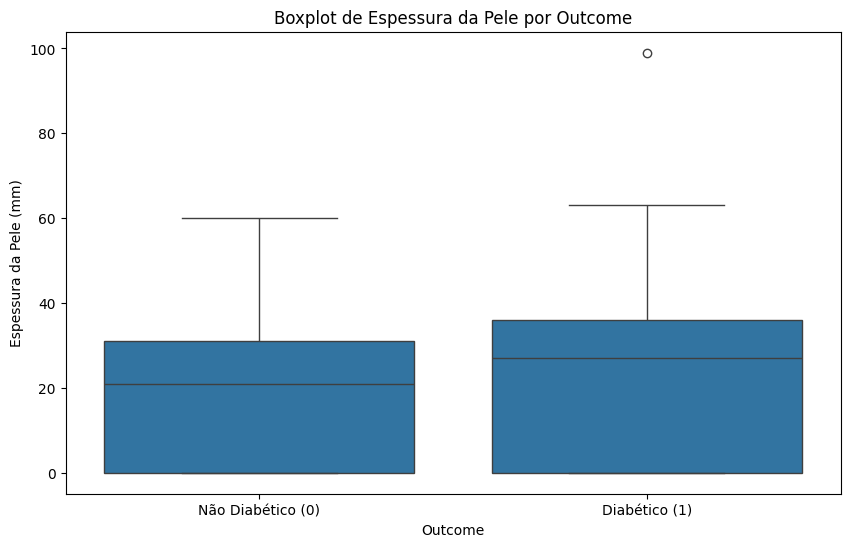

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Outcome', y='SkinThickness', data=dados)
plt.title('Boxplot de Espessura da Pele por Outcome')
plt.xlabel('Outcome')
plt.ylabel('Espessura da Pele (mm)')
plt.xticks(outcome, labels=labels)
plt.savefig('../Graficos/boxplot_skinthickness.png', dpi=150, bbox_inches='tight')
plt.show()


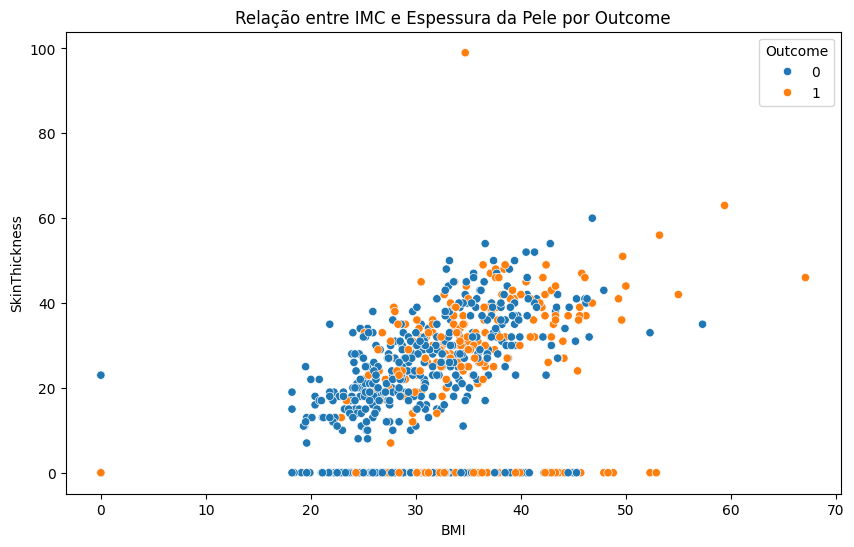

In [29]:
plt.figure(figsize=(10, 6))
ax = sns.scatterplot(x='BMI', y='SkinThickness', hue='Outcome', data=dados)
ax.set_title('Relação entre IMC e Espessura da Pele por Outcome')
plt.savefig('../Graficos/relacao_bmi_skinthickness.png', dpi=150, bbox_inches='tight')
plt.show()  

A espessura da pele cresce junto com o valor de IMC. 
O valor de IMC pode ser mais adequado para o modelo pois está com informações mais completas, e pode trazer menos viés ao modelo. 

### Gestações (Pregnancies)

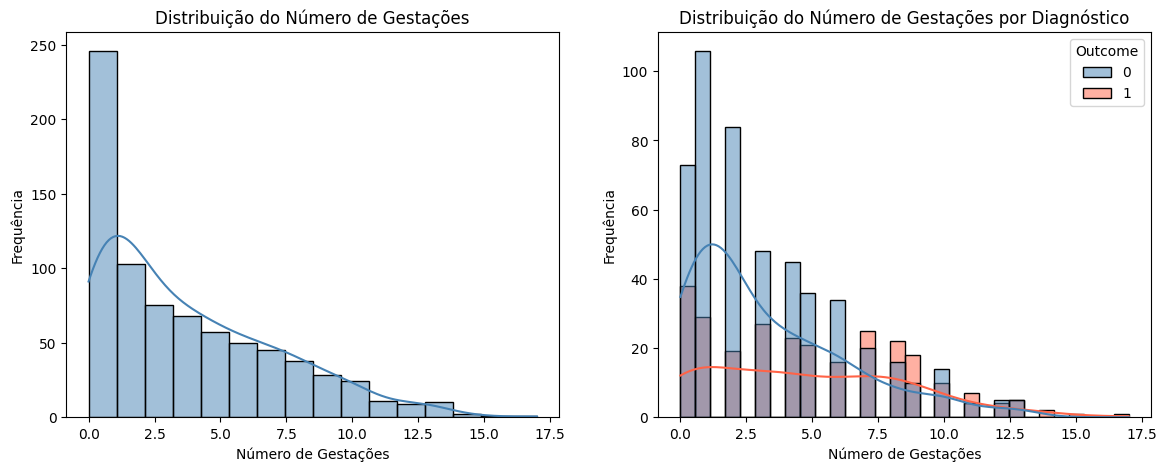

In [30]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.histplot(dados['Pregnancies'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribuição do Número de Gestações')
axes[0].set_xlabel('Número de Gestações')
axes[0].set_ylabel('Frequência')
sns.histplot(data=dados, x='Pregnancies', hue='Outcome', kde=True, bins=30, alpha=0.5, ax=axes[1], palette=color)
axes[1].set_title('Distribuição do Número de Gestações por Diagnóstico')
axes[1].set_xlabel('Número de Gestações')
axes[1].set_ylabel('Frequência')
plt.savefig('../Graficos/distribuicao_pregnancies.png', dpi=150, bbox_inches='tight')
plt.show()

Os valores zerados de gravidez é uma medida válida pois indicam mulheres sem filhos.

### Análise de correlação. 

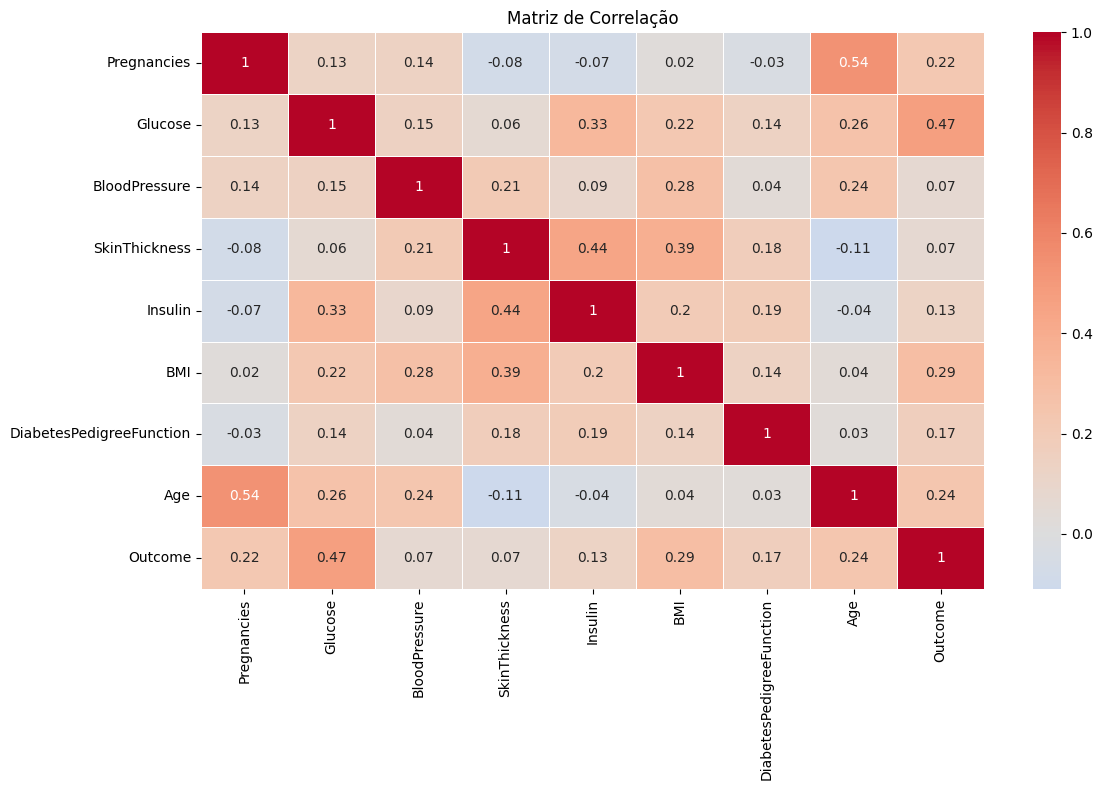


=== CORRELAÇÃO COM OUTCOME (ordenada) ===
Glucose                     0.47
BMI                         0.29
Age                         0.24
Pregnancies                 0.22
DiabetesPedigreeFunction    0.17
Insulin                     0.13
SkinThickness               0.07
BloodPressure               0.07
Name: Outcome, dtype: float64


In [31]:
#matriz de correlação
correlacao = dados.corr().round(2)

plt.figure(figsize=(12, 8)) 
sns.heatmap(correlacao, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de Correlação')
plt.tight_layout()
plt.savefig('../Graficos/matriz_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== CORRELAÇÃO COM OUTCOME (ordenada) ===')
print(correlacao['Outcome'].drop('Outcome').sort_values(ascending=False).round(3))

No gráfico de correlação podemos notar que:
- A variável de glicose é a que mais influencia o outcome positivo.
- Glicose e Insulina tem alguma correlação. 
- A correlação entre idade e gestações só nos diz que ao avançar da idade aumenta o número de gestações
- Indivíduos com maior IMC tem maior espessura da pele (SkinThickness)

## Conclusões de exploração dos dados:

**Resumo dos achados:**

1. **Dataset:** 768 pacientes, 8 features numéricas + 1 variável alvo (Outcome)
2. **Valores ausentes:** nenhum valor nulo explícito, porém há zeros suspeitos em colunas como Glucose, BloodPressure, SkinThickness, Insulin e BMI
3. **Desbalanceamento:** ~65% sem diabetes (0) e ~35% com diabetes (1) — dataset moderadamente desbalanceado
4. **Features mais correlacionadas com Outcome:** Glucose apresenta a maior correlação positiva, seguida de BMI e Age
5. **Próximo passo:** pré-processamento (tratar zeros suspeitos, escalar features, separar treino/teste)

## Pré-processamento

- Tratamento de zeros suspeitos
- Escalonamento de features
- Separação entre treino e teste

In [32]:
import numpy as np

dados_clean = dados.copy()
colunas_com_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
dados_clean[colunas_com_zero] = dados_clean[colunas_com_zero].replace(0, np.nan)

print('=== VALORES NULOS APÓS SUBSTITUIÇÃO DE ZEROS ===')
print(dados_clean.isnull().sum())

=== VALORES NULOS APÓS SUBSTITUIÇÃO DE ZEROS ===
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


**O tratamento de dados zerados será feito após a separação dos dados em treino e teste.**
**Para evitar concentração muito grande de valores na mediana,**
**iremos utilizar o KNN Imputer, que necessita de padronização dos dados antes da imputação.**

In [32]:
# O tratamento de dados zerados será feito após a separação dos dados em treino e teste. 
# Para evitar concentração muito grande de valores na mediana,
# iremos utilizar o KNN Imputer, que necessidade de padronização dos dados antes da imputação.

#from sklearn.impute import SimpleImputer
#imputer = SimpleImputer(strategy='median')
#dados_imputados = pd.DataFrame(imputer.fit_transform(dados_clean), columns=dados_clean.columns)

#print('=== VALORES NULOS APÓS IMPUTAÇÃO ===')
#print(dados_imputados.isnull().sum())

#dados_imputados.head()


SkinThickness e Insulin ficaram com uma distribuição muito alta na mediana.

## Separação do modelo entre treino e teste

- Vamos usar o stratify para balancear a quantidade de dados em treino e teste

In [33]:
X = dados_clean.drop(columns='Outcome')
y = dados_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Verificar a proporção dos dados separados entre treino e teste:

In [34]:
tabela_proporcao = pd.DataFrame({
    'Conjunto': ['Treino', 'Treino', 'Teste', 'Teste'],
    'Diagnóstico': ['Positivo (1)', 'Negativo (0)', 'Positivo (1)', 'Negativo (0)'],
    'Quantidade': [
        (y_train == 1).sum(),
        (y_train == 0).sum(),
        (y_test == 1).sum(),
        (y_test == 0).sum()
    ],
    'Proporção': [
        f"{(y_train == 1).mean().round(2):.0%}",
        f"{(y_train == 0).mean().round(2):.0%}",
        f"{(y_test == 1).mean().round(2):.0%}",
        f"{(y_test == 0).mean().round(2):.0%}"
    ]
})
print('=== TABELA DE PROPORÇÃO DE DIAGNÓSTICOS NOS CONJUNTOS DE TREINO E TESTE ===')
tabela_proporcao

=== TABELA DE PROPORÇÃO DE DIAGNÓSTICOS NOS CONJUNTOS DE TREINO E TESTE ===


,Conjunto,Diagnóstico,Quantidade,Proporção
0,Treino,Positivo (1),214,35%
1,Treino,Negativo (0),400,65%
2,Teste,Positivo (1),54,35%
3,Teste,Negativo (0),100,65%


A separação entre treino e teste manteve a proporção de diagnósticos

### Feature Scaling

In [35]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

X_train_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.851355,-1.054083,-0.811546,-1.623570,-0.990735,-0.764137,0.310794,-0.792169
1,0.356576,0.142921,0.468304,-0.195982,-1.186870,-0.414746,-0.116439,0.561034
2,-0.549372,-0.555331,-1.131508,1.041261,-0.514407,0.356827,-0.764862,-0.707594
3,-0.851355,0.807923,-1.291489,NaN,NaN,-0.400188,0.262314,-0.369293
4,-1.153338,-0.887832,-0.651565,0.946089,-0.411670,1.768950,-0.337630,-0.961320


## Tratamento de zeros com KNNImputer

In [36]:
#KNN Imputer
imputer = KNNImputer(n_neighbors=5)
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)


In [37]:
dados_treinamento = pd.DataFrame(X_train_scaled, columns=X_train.columns)
dados_treinamento.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,-0.851355,-1.054083,-0.811546,-1.623570,-0.990735,-0.764137,0.310794,-0.792169
1,0.356576,0.142921,0.468304,-0.195982,-1.186870,-0.414746,-0.116439,0.561034
2,-0.549372,-0.555331,-1.131508,1.041261,-0.514407,0.356827,-0.764862,-0.707594
3,-0.851355,0.807923,-1.291489,-0.024671,-0.116534,-0.400188,0.262314,-0.369293
4,-1.153338,-0.887832,-0.651565,0.946089,-0.411670,1.768950,-0.337630,-0.961320


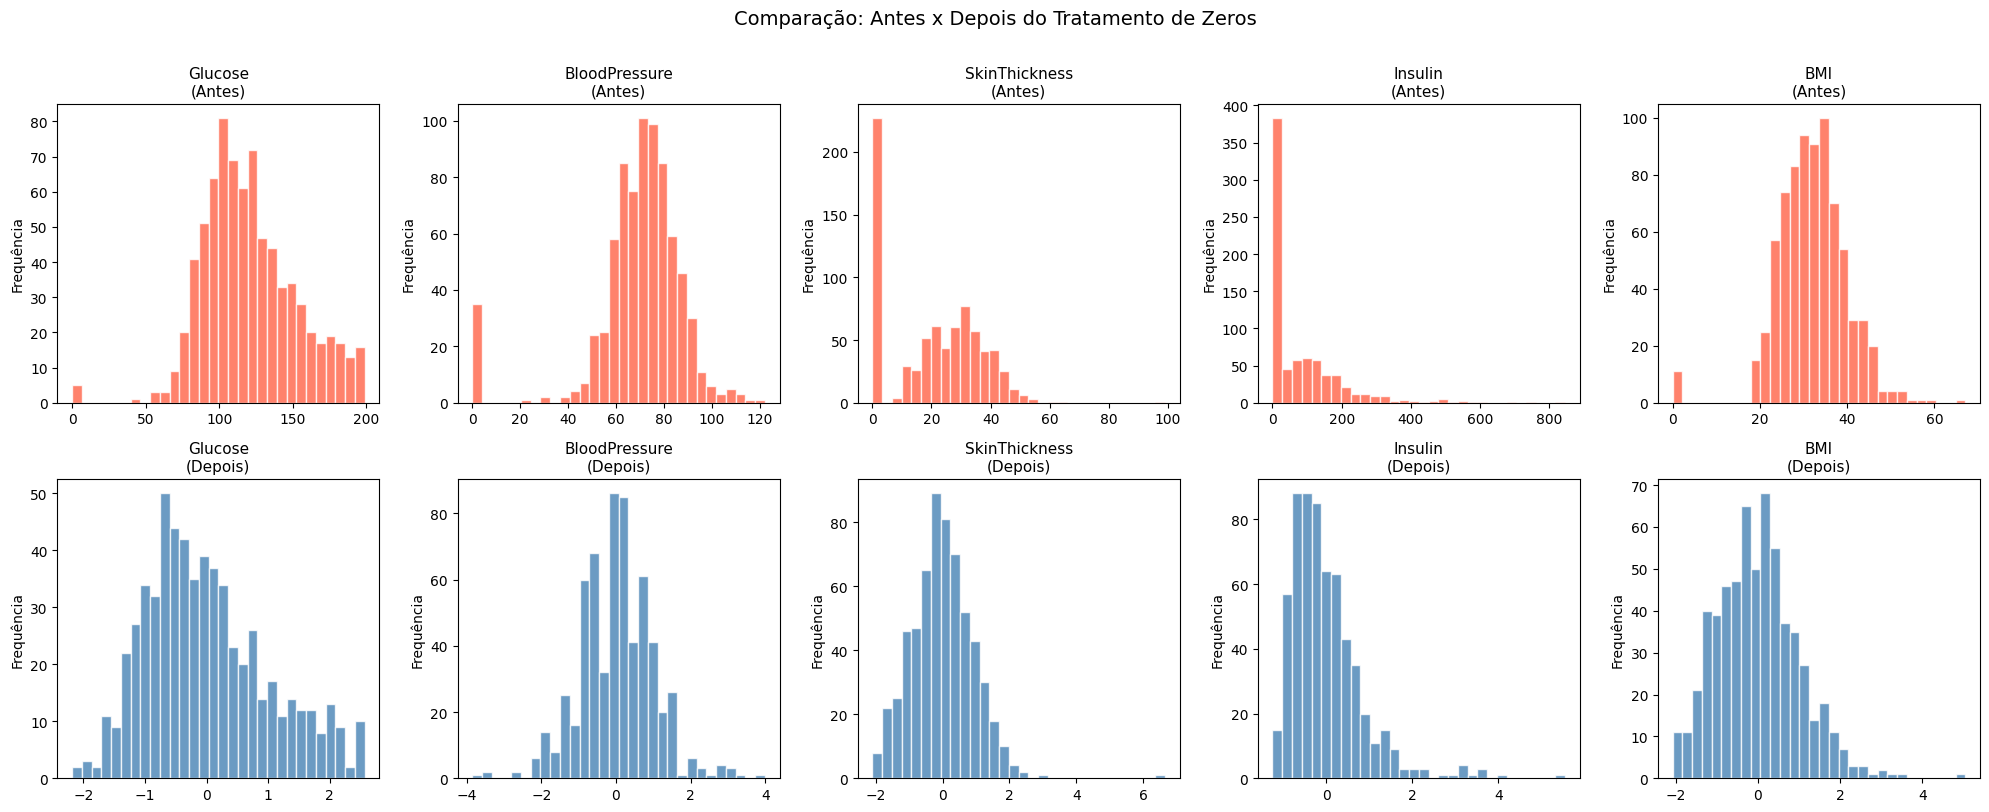

In [38]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, col in enumerate(colunas_com_zero):
    # Antes
    axes[0, i].hist(dados[col], bins=30, color='tomato', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col}\n(Antes)', fontsize=11)
    axes[0, i].set_ylabel('Frequência')

    # Depois
    axes[1, i].hist(dados_treinamento[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'{col}\n(Depois)', fontsize=11)
    axes[1, i].set_ylabel('Frequência')

plt.suptitle('Comparação: Antes x Depois do Tratamento de Zeros', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../Graficos/comparacao_tratamento_zeros.png', dpi=150, bbox_inches='tight')
plt.show()

## Treinamento do modelo


Este notebook treina e avalia três modelos de classificação:
- **K Nearest Neighbors**
- **SVM - Support Vector Machine**
- **Random Forest**

A métrica principal é o **Recall**, pois em diagnóstico médico um falso negativo
(não detectar diabetes em quem tem) é mais prejudicial que um falso positivo.

### KNN - K Nearest Neighbors

Primeiramente, vamos descobrir o melhor valor de K

In [39]:
error = []

for i in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    error.append(np.mean(y_pred != y_test))

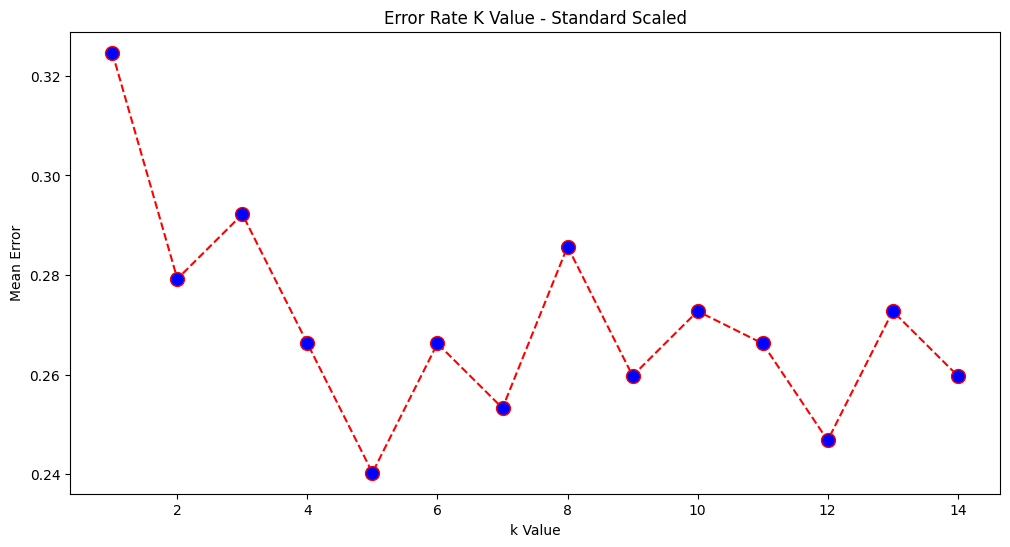

In [40]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 15), error, color='red', linestyle='dashed', marker='o', markerfacecolor='blue', markersize=10)
plt.xlabel('k Value')
plt.ylabel('Mean Error')
plt.title('Error Rate K Value - Standard Scaled')
plt.show()

O melhor k encontrado foi 5, que representa a menor taxa de erro médio. 

In [41]:
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)

### SVM - Support Vector Machine

In [45]:
#SVM
model_svm = SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced')
model_svm.fit(X_train_scaled, y_train)
y_pred_svm = model_svm.predict(X_test_scaled)


Foram feitos testes utilizando o kernel linear, mas o kernel rbf retornou um resultado ligeiramente melhor na métrica de recall. 

- Devido a dataset desbalanceado, mantemos o class_weight com valor balanced
- Utilizaremos o flag de probabilidade como True para as avaliações e interpretabilidade

### Random Forest

In [43]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

### Avaliação das Métricas de cada modelo

In [46]:
def avaliar_modelo(nome, y_real, y_previsto):
    acc = accuracy_score(y_real, y_previsto)
    rec = recall_score(y_real, y_previsto)
    f1  = f1_score(y_real, y_previsto)
    print(f'\n=== {nome} ===')
    print(f'  Accuracy:  {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Recall:    {rec:.4f} ({rec*100:.2f}%)')
    print(f'  F1-Score:  {f1:.4f}')
    print(classification_report(y_real, y_previsto, target_names=['Sem Diabetes', 'Com Diabetes']))      
    return acc, rec, f1

acc_knn, rec_knn, f1_knn = avaliar_modelo('KNN', y_test, y_pred_knn)
acc_svm, rec_svm, f1_svm = avaliar_modelo('SVM', y_test, y_pred_svm)
acc_rf, rec_rf, f1_rf = avaliar_modelo('Random Forest', y_test, y_pred_rf)



=== KNN ===
  Accuracy:  0.7597 (75.97%)
  Recall:    0.5741 (57.41%)
  F1-Score:  0.6263
              precision    recall  f1-score   support

Sem Diabetes       0.79      0.86      0.82       100
Com Diabetes       0.69      0.57      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.72       154
weighted avg       0.75      0.76      0.75       154


=== SVM ===
  Accuracy:  0.7143 (71.43%)
  Recall:    0.7222 (72.22%)
  F1-Score:  0.6393
              precision    recall  f1-score   support

Sem Diabetes       0.83      0.71      0.76       100
Com Diabetes       0.57      0.72      0.64        54

    accuracy                           0.71       154
   macro avg       0.70      0.72      0.70       154
weighted avg       0.74      0.71      0.72       154


=== Random Forest ===
  Accuracy:  0.7468 (74.68%)
  Recall:    0.5741 (57.41%)
  F1-Score:  0.6139
              precision    recall  f1-score   support

Sem Diab

O modelo de SVM conseguiu um melhor recall e F1-Score. 

### Matriz de confusão

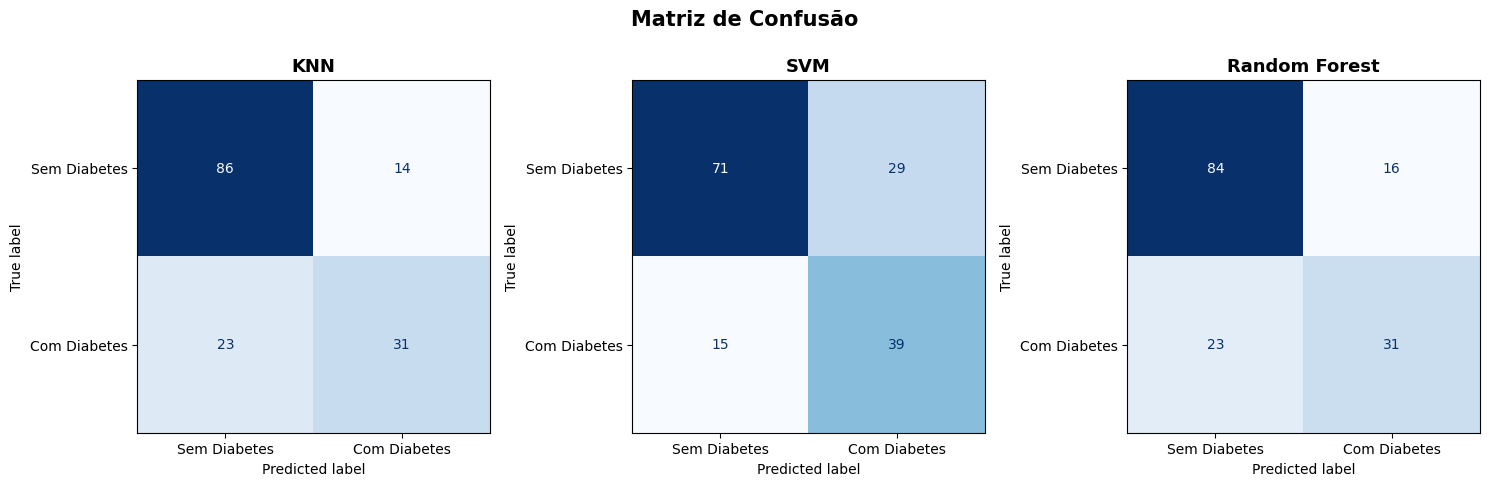

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, y_pred, titulo in zip(axes.flatten(),
                               [y_pred_knn, y_pred_svm, y_pred_rf],
                               ['KNN', 'SVM', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Sem Diabetes', 'Com Diabetes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(titulo, fontsize=13, fontweight='bold')

plt.suptitle('Matriz de Confusão', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../Graficos/grafico_matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

### Curva ROC

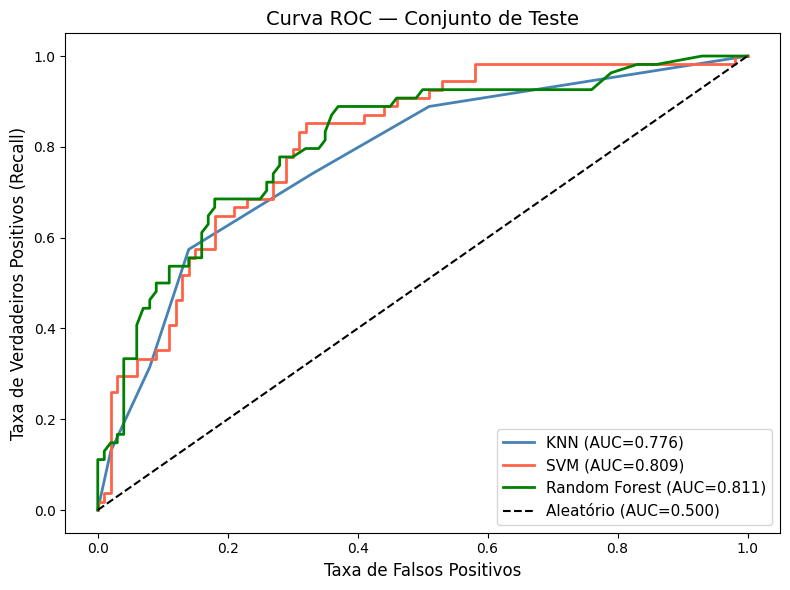

In [48]:
#Curva ROC
fig, ax = plt.subplots(figsize=(8, 6))

for modelo, nome, cor, x_test_roc in [
    (model_knn, 'KNN', 'steelblue', X_test_scaled),
    (model_svm, 'SVM', 'tomato', X_test_scaled),
    (model_rf, 'Random Forest', 'green', X_test)
]:
    y_prob = modelo.predict_proba(x_test_roc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{nome} (AUC={auc:.3f})', color=cor, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC=0.500)')
ax.set_xlabel('Taxa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Taxa de Verdadeiros Positivos (Recall)', fontsize=12)
ax.set_title('Curva ROC — Conjunto de Teste', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../graficos/curva_roc.png', dpi=150)
plt.show()

Considerando que para um modelo excelente, a curva alcançaria o valor 1.0 do eixo y, e um valor de AUC de 0.5 seria como um "palpite" aleatório.

- Os 3 modelos apresentam AUC score muito bom
- Sendo assim, indicam boa capacidade de discriminar pacientes diabéticos de não diabéticos
- Os modelos SVM e RandomForest apresentam o melhor resultado, apesar do modelo KNN não ficar muito atrás 
    - Neste momento, vamos considerar o modelo **SVM** como o melhor modelo devido ao melhor score de recall. 

# Interpretabilidade

Vamos considerar o modelo com melhor métrica de recall, dadas as características do modelo:
- **SVM - Support Vector Machine**

A seguir são apresentadas técnicas de interpretabilidade para entender quais features
mais influenciam as predições:
- **Feature Importance**
- **SHAP** (SHapley Additive exPlanations)

### Feature Importances

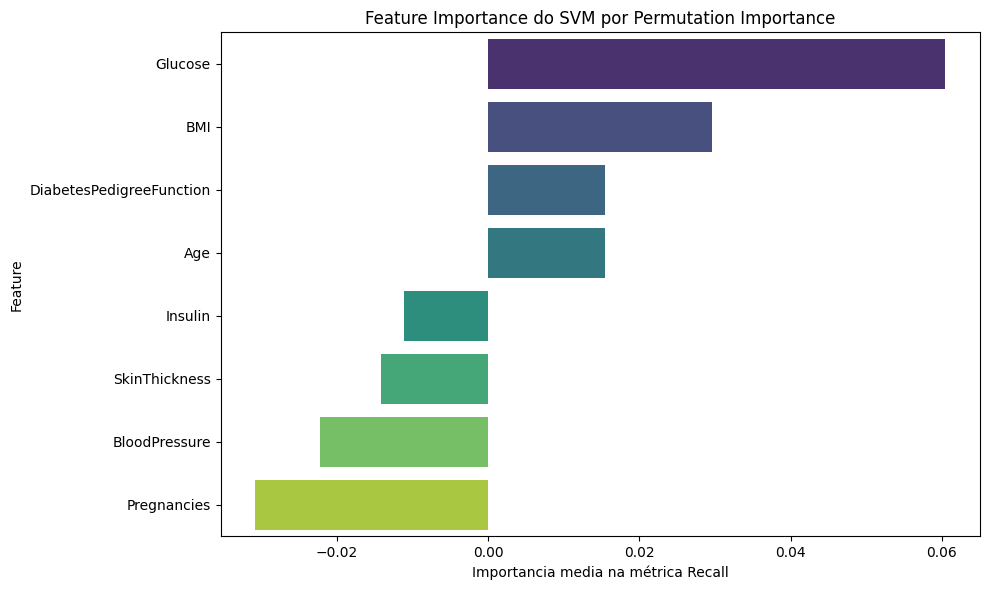

,Feature,Importancia Media,Desvio Padrao
1,Glucose,0.060494,0.041666
5,BMI,0.029630,0.026878
6,DiabetesPedigreeFunction,0.015432,0.030647
7,Age,0.015432,0.032809
4,Insulin,-0.011111,0.031208
3,SkinThickness,-0.014198,0.019530
2,BloodPressure,-0.022222,0.018144
0,Pregnancies,-0.030864,0.030366


In [49]:
# Feature Importance de SVM
importances_svm = permutation_importance(
    model_svm,
    X_test_scaled,
    y_test,
    n_repeats=30,
    random_state=42,
    scoring='recall'
)

feature_importance_svm = pd.DataFrame({
    'Feature': X.columns,
    'Importancia Media': importances_svm.importances_mean,
    'Desvio Padrao': importances_svm.importances_std
}).sort_values('Importancia Media', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance_svm,
    x='Importancia Media',
    y='Feature',
    palette='viridis',
    hue='Feature',
    legend=False
)
plt.title('Feature Importance do SVM por Permutation Importance')
plt.xlabel('Importancia media na métrica Recall')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../Graficos/feature_importance_svm.png', dpi=150, bbox_inches='tight')
plt.show()

feature_importance_svm


- A feature de Glicose (Glucose) demonstra ser de longe a feature que mais impacta no resultado da predição do modelo.

### SHAP - SVM

SHAP (SHapley Additive exPlanations) explica a contribuição de cada feature
para cada predição individual, com base na teoria dos jogos cooperativos.

É mais robusto que feature importance pois considera interações entre features.

### Shap Summary Plot (Impacto Global de cada feature)

In [50]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

background_data = shap.sample(X_train_scaled_df, 100, random_state=42)
explainer = shap.KernelExplainer(model_svm.predict_proba, background_data)
shap_values = explainer.shap_values(X_test_scaled_df)

print(f'SHAP values calculados para {X_test_scaled_df.shape[0]} amostras de teste')
print(type(shap_values))



  0%|          | 0/154 [00:00<?, ?it/s]

100%|██████████| 154/154 [03:32<00:00,  1.38s/it]

SHAP values calculados para 154 amostras de teste
<class 'numpy.ndarray'>


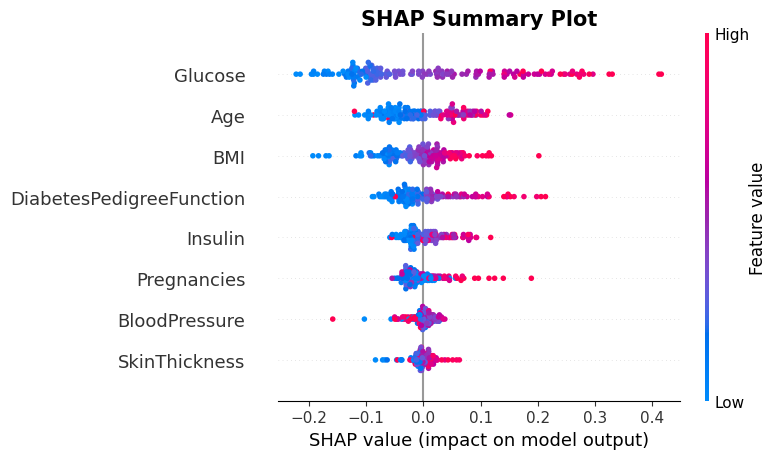

In [51]:
plt.figure(figsize=(12, 8))
plt.title('SHAP Summary Plot', fontsize=15, fontweight='bold')
shap.summary_plot(shap_values[:,:,1], X_test_scaled_df, feature_names=X.columns, plot_type="dot", show=False)
plt.savefig('../Graficos/shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

O gráfico SHAP demonstra que as variáveis mais relevantes para a classificação foram Glucose, BMI, Pregnancies e DiabetesPedigreeFunction. Valores elevados dessas variáveis tendem a aumentar a probabilidade prevista de diabetes, enquanto valores baixos contribuem negativamente para essa previsão. As demais variáveis apresentam impacto significativamente menor, com destaque para BloodPressure e SkinThickness, que praticamente não influenciam as decisões do modelo.

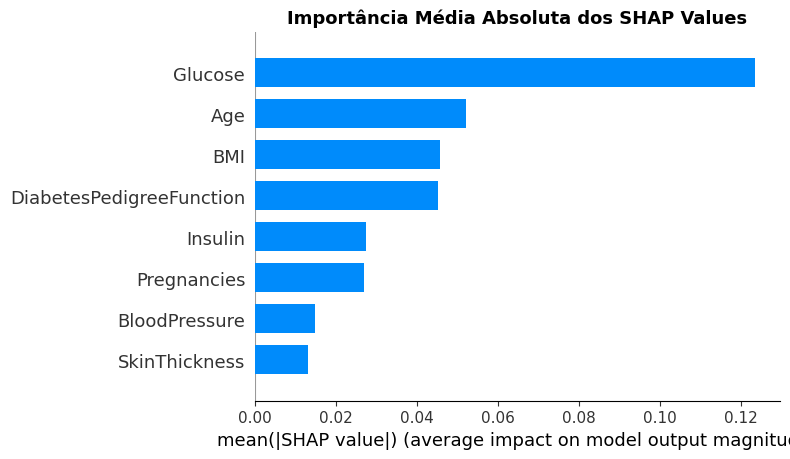

In [52]:
shap.summary_plot(shap_values[:, :, 1], X_test_scaled_df, feature_names=X.columns, plot_type='bar', show=False)
plt.title('Importância Média Absoluta dos SHAP Values', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../Graficos/shap_summary_importance.png', dpi=150, bbox_inches='tight')
plt.show()


A análise de importância média absoluta dos valores SHAP mostrou que a variável Glucose é a mais influente no processo de classificação, seguida por Age, BMI e DiabetesPedigreeFunction. Juntas, essas variáveis concentram a maior parte da capacidade preditiva do modelo. Variáveis como BloodPressure e SkinThickness apresentaram contribuição muito baixas para as decisões do modelo.

Paciente analisado: índice 7
Diagnóstico real: Com Diabetes
Predição do modelo: Com Diabetes
Probabilidade de diabetes: 58.20%


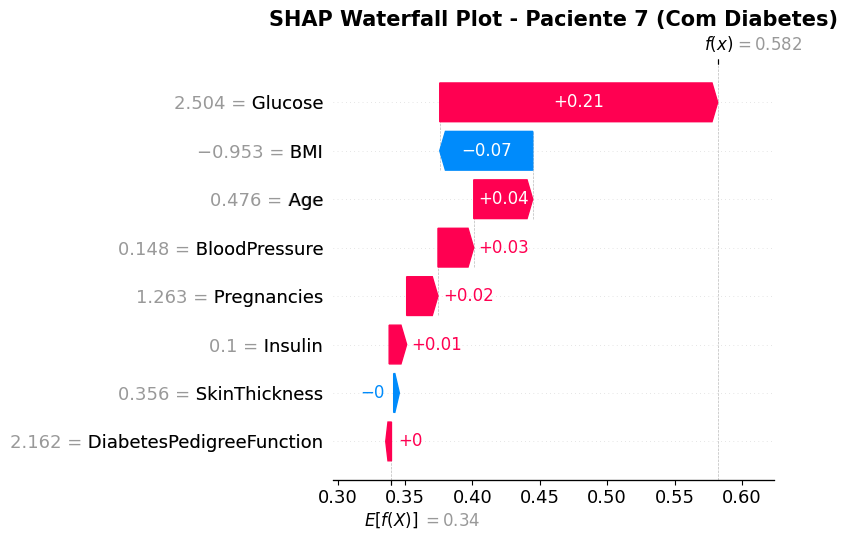

In [53]:
# Escolher um paciente com diabetes real (y_test == 1)
idx_diabetico = np.where(y_test == 1)[0][2]  # Terceiro paciente diabético do conjunto de teste

print(f'Paciente analisado: índice {idx_diabetico}')
print(f'Diagnóstico real: {"Com Diabetes" if y_test.iloc[idx_diabetico] == 1 else "Sem Diabetes"}')
pred = model_knn.predict(X_test_scaled[[idx_diabetico]])[0]
print(f'Predição do modelo: {"Com Diabetes" if pred == 1 else "Sem Diabetes"}')
print(f'Probabilidade de diabetes: {model_svm.predict_proba(X_test_scaled[[idx_diabetico]])[0][1]:.2%}')

single_explanation = shap.Explanation(values=shap_values[idx_diabetico, :, 1],
                                      base_values=explainer.expected_value[1],
                                      data=X_test_scaled_df.iloc[idx_diabetico],
                                      feature_names=X.columns)

shap.plots.waterfall(single_explanation, max_display=10, show=False)
plt.title(f'SHAP Waterfall Plot - Paciente {idx_diabetico} (Com Diabetes)', fontsize=15, fontweight='bold')
plt.tight_layout()  
plt.savefig(f'../Graficos/shap_waterfall_paciente_{idx_diabetico}.png', dpi=150, bbox_inches='tight')
plt.show()

### Localização do paciente no dataset

In [54]:
indice_original = y_test.index[idx_diabetico]
print(f'Índice original do paciente no dataset: {indice_original}')
dados.query(f'index == {indice_original}').head()

Índice original do paciente no dataset: 408


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
408,8,197,74,0,0,25.9,1.191,39,1


#### Dados escalonados do paciente que aparecem no SHAP Waterfall

In [55]:
df = pd.DataFrame(X_test_scaled[idx_diabetico], index=X.columns, columns=['Valor Padronizado'])
df

,Valor Padronizado
Pregnancies,1.262524
Glucose,2.503679
BloodPressure,0.148341
SkinThickness,0.356019
Insulin,0.100149
BMI,-0.953391
DiabetesPedigreeFunction,2.162134
Age,0.476459


# Conclusões

Neste trabalho, foram desenvolvidos três modelos de classificação (K-Nearest Neighbors, Random Forest e Support Vector Machine) para prever a presença de diabetes a partir de variáveis clínicas como glucose (glicose), BMI (IMC), Age (idade), pregnancies (gestações).

**Achados principais:**

1. **Glucose** é consistentemente a feature mais importante — alto nível de glicose é o principal preditor de diabetes, alinhado com o conhecimento clínico
2. **BMI**, **Pregnancies** e **Age** aparecem como próximos fatores mais relevantes
3. **Insulin** não mostrou muita relevância para o modelo apesar de ter uma correlação relevante com **Glucose**, talvez devido a ter uma alta porcentagens de dados faltantes.
3. **BloodPressure** e **SkinThickness** têm baixa importância — podem ter pouco poder preditivo neste dataset
4. O SHAP elenca claramente o ranking de features mais importantes na predição do modelo.
4. O SHAP Waterfall mostra como interpretar a predição de um paciente individual, tornando o modelo auditável por profissionais de saúde

**Implicação clínica:**

O modelo pode ser usado como ferramenta de triagem, priorizando pacientes com glicose elevada, IMC alto e idade avançada para avaliação médica detalhada. A transparência dos valores SHAP permite que o(a) médico(a) entenda e questione cada predição, mantendo o controle clínico sobre o diagnóstico final.

**Limitações:**
1. **Dados ausentes disfarçados de zero:** colunas como insulina (49% dos registros), espessura da pele (29,6%) e pressão (4,6%) continham valores zero fisiologicamente impossíveis, que precisaram ser substituídos pela mediana. Essa imputação massiva, especialmente na insulina, reduz a confiabilidade dessa variável — fato confirmado pelo gráfico SHAP, onde a insulina aparece com baixo impacto nas previsões, possivelmente por causa da imputação e não por ausência real de relevância clínica.
2. **Tamanho da amostra:** apenas 768 pacientes, o que limita a capacidade de generalização do modelo para outras populações.
3. **Origem dos dados:** o dataset é composto exclusivamente por mulheres de uma etnia específica (Pima Indians), o que pode não representar bem outras populações.
4. **Desbalanceamento de classes:** 65% dos pacientes não têm diabetes contra 35% que têm, o que pode enviesar o modelo a favor da classe majoritária.

**Conclusão final:** O modelo de Support Vector Machine se mostrou mais adequado para este treinamento, priorizando a identificação de casos positivos (maior recall). Contudo, dada a natureza crítica de diagnósticos médicos e as limitações dos dados, o modelo deve ser tratado como uma ferramenta complementar de apoio à decisão clínica, não como substituto da avaliação médica.